In [1]:
# We fit this model with the time distribution layer. Notebook carries the code for training the base model. Posthoc normalization and evaluation metrics done in the corresponding notebook 8.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

2025-06-25 16:31:38.756750: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 16:31:38.791496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-25 16:31:38.791519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-25 16:31:38.792340: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-25 16:31:38.797963: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# We need to locate the data? Need to think what we will use for training the data - the same data we used for training the seq-2-seq model? At least the input features part there

In [4]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
# location of the data? Input features
all_train_path = "seq_2_seq_train_data"

In [6]:
# all contents here?
os.listdir(all_train_path)

['block_0101_extracted_input_features.npy',
 'block_0101_extracted_target_features.npy',
 'block_0301_extracted_target_features.npy',
 'block_0102_extracted_input_features.npy',
 'block_0203_extracted_target_features.npy',
 'block_0301_extracted_input_features.npy',
 'block_0203_extracted_input_features.npy',
 'block_0102_extracted_target_features.npy']

In [7]:
# we only need the feature matrices
all_train_features_names = [file for file in os.listdir(all_train_path) if file.split(".")[0][-14:] == "input_features"]

In [8]:
all_train_features_names.sort()

In [9]:
all_train_features_names

['block_0101_extracted_input_features.npy',
 'block_0102_extracted_input_features.npy',
 'block_0203_extracted_input_features.npy',
 'block_0301_extracted_input_features.npy']

In [10]:
# load the feature files
all_train_feature_matrices = [np.load(os.path.join(all_train_path, file_name)) for file_name in all_train_features_names]

In [11]:
# stack all these together
all_train_features = np.vstack(all_train_feature_matrices)

In [12]:
all_train_features.shape

(3640, 13, 32)

In [13]:
# Also load the validation features?
all_val_path = "seq_2_seq_valid_data"

In [14]:
os.listdir(all_val_path)

['block_0204_extracted_input_features.npy',
 'block_0204_extracted_target_features.npy']

In [15]:
all_valid_features = np.load(os.path.join(all_val_path, "block_0204_extracted_input_features.npy"))

In [16]:
all_valid_features.shape

(910, 13, 32)

In [17]:
# Okay, where are the stacked densities?
all_target_density_paths = "stacked_densities"

In [18]:
os.listdir(all_target_density_paths)

['stacked_densities_block_0104.npy',
 'stacked_densities_block_0101.npy',
 'stacked_densities_block_0103.npy',
 'stacked_densities_block_0306.npy',
 'stacked_densities_block_0302.npy',
 'stacked_densities_block_0205.npy',
 'stacked_densities_block_0304.npy',
 'stacked_densities_block_0303.npy',
 'stacked_densities_block_0201.npy',
 'stacked_densities_block_0102.npy',
 'stacked_densities_block_0206.npy',
 'stacked_densities_block_0204.npy',
 'stacked_densities_block_0203.npy',
 'stacked_densities_block_0106.npy',
 'stacked_densities_block_0105.npy',
 'stacked_densities_block_0301.npy',
 'stacked_densities_block_0202.npy',
 'stacked_densities_block_0305.npy']

In [19]:
train_blocks = ["0101", "0102", "0203", "0301"]

In [20]:
train_density_files = [file for file in os.listdir(all_target_density_paths) if file.split(".")[0][-4:] in train_blocks]
train_density_files.sort()

In [21]:
train_density_files

['stacked_densities_block_0101.npy',
 'stacked_densities_block_0102.npy',
 'stacked_densities_block_0203.npy',
 'stacked_densities_block_0301.npy']

In [22]:
# load the train densities
all_train_density_vectors = [np.load(os.path.join(all_target_density_paths, file_name)) for file_name in train_density_files]

In [23]:
all_train_density_vectors[0].shape

(910, 7)

In [24]:
# stack all these densities together?
all_train_targets = np.vstack(all_train_density_vectors)

In [25]:
all_train_targets.shape

(3640, 7)

In [26]:
# load the validation densities
all_valid_targets = np.load(os.path.join(all_target_density_paths, "stacked_densities_block_0204.npy"))

In [27]:
all_valid_targets.shape

(910, 7)

Train the model - with the time distributed layer

In [28]:
# define the model
inputs = tf.keras.Input(shape=(13, 32))
x = tf.keras.layers.LSTM(16)(inputs)
outputs = tf.keras.layers.Dense(7)(x)
ts_similar_model = tf.keras.Model(inputs, outputs)

ts_similar_model.summary()

2025-06-25 16:31:40.898375: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:06:00.0, compute capability: 7.0


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 32)]          0         
                                                                 
 lstm (LSTM)                 (None, 16)                3136      
                                                                 
 dense (Dense)               (None, 7)                 119       
                                                                 
Total params: 3255 (12.71 KB)
Trainable params: 3255 (12.71 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("models/stage2_basemodel2.keras", save_best_only=True), tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=15)]

In [30]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
ts_similar_model.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])

In [31]:
history = ts_similar_model.fit(all_train_features, all_train_targets,
          epochs = 300, callbacks = callbacks,
          validation_data = (all_valid_features, all_valid_targets), 
                       batch_size = 1000, validation_batch_size = 1000)

Epoch 1/300


2025-06-25 16:31:42.579593: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-06-25 16:31:42.957698: I external/local_xla/xla/service/service.cc:168] XLA service 0x14f43ec65220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-25 16:31:42.957724: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-06-25 16:31:42.962370: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750887103.069145 2392442 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 [==============================] - 2s 124ms/step - loss: 0.0632 - mean_absolute_error: 0.1998 - val_loss: 0.0365 - val_mean_absolute_error: 0.1426
Epoch 2/300
4/4 [==============================] - 0s 21ms/step - loss: 0.0411 - mean_absolute_error: 0.1371 - val_loss: 0.0263 - val_mean_absolute_error: 0.1121
Epoch 3/300
4/4 [==============================] - 0s 23ms/step - loss: 0.0348 - mean_absolute_error: 0.1160 - val_loss: 0.0207 - val_mean_absolute_error: 0.0910
Epoch 4/300
4/4 [==============================] - 0s 30ms/step - loss: 0.0300 - mean_absolute_error: 0.0940 - val_loss: 0.0164 - val_mean_absolute_error: 0.0649
Epoch 5/300
4/4 [==============================] - 0s 36ms/step - loss: 0.0266 - mean_absolute_error: 0.0744 - val_loss: 0.0148 - val_mean_absolute_error: 0.0530
Epoch 6/300
4/4 [==============================] - 0s 22ms/step - loss: 0.0254 - mean_absolute_error: 0.0680 - val_loss: 0.0145 - val_mean_absolute_error: 0.0513
Epoch 7/300
4/4 [======================

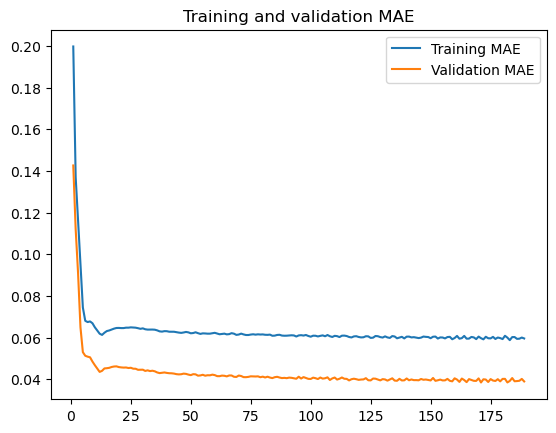

In [32]:
loss = history.history["mean_absolute_error"]
val_loss = history.history["val_mean_absolute_error"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, label="Training MAE")
plt.plot(epochs, val_loss, label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [33]:
# verify the model is indeed the correct model - chack the validation metrics

In [34]:
loaded_model = tf.keras.models.load_model("models/stage2_basemodel2.keras")

In [35]:
val_preds = loaded_model.predict(all_valid_features)

29/29 [==============================] - 0s 3ms/step


In [36]:
val_preds = val_preds.reshape(val_preds.shape[0],val_preds.shape[1])

In [37]:
val_preds.shape

(910, 7)

In [38]:
all_valid_targets.shape

(910, 7)

In [39]:
# mean absolute error
np.mean(abs(val_preds - all_valid_targets))

0.03868701769636826

In [40]:
# root mean squared error
np.mean((val_preds - all_valid_targets)**2)

0.012940063351309164

In [41]:
# verify using tf metrics
# define the MAE metric
mae_metric_valid = tf.keras.metrics.MeanAbsoluteError()

In [42]:
# update the state of the metric
mae_metric_valid.update_state(all_valid_targets, val_preds)

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=910.0>

In [43]:
# Get the result
mae_valid = mae_metric_valid.result().numpy()

In [44]:
mae_valid # This value match the one during training in script 2

0.038687017

In [45]:
# Also get the rmse?

# define the MSE metric
mse_metric_valid = tf.keras.metrics.MeanSquaredError()

In [46]:
# update the state of the metric
mse_metric_valid.update_state(all_valid_targets, val_preds)

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=910.0>

In [47]:
# get the result
mse_valid = mse_metric_valid.result().numpy()
mse_valid

0.012940063